Testing Damping on a highly non-linear problem
Damped NR: Successfully converged to V=2.000 in 6 iterations!

Performance Comparison
Metric               | Fixed (h=0.01)  | Adaptive (tol=1e-4)
-------------------------------------------------------
Total Time Steps     | 1002            | 12             
Total NR Iters       | 2002            | 72             
Rejected Steps       | N/A             | 0              

Robustness Testing
Huge initial h (1.0) handled. First valid h used: 1.0000
Extreme tol (1e-8) handled. Average h used: 0.05128


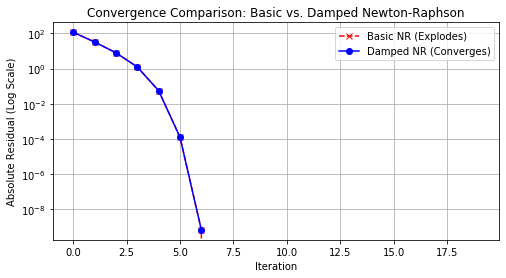

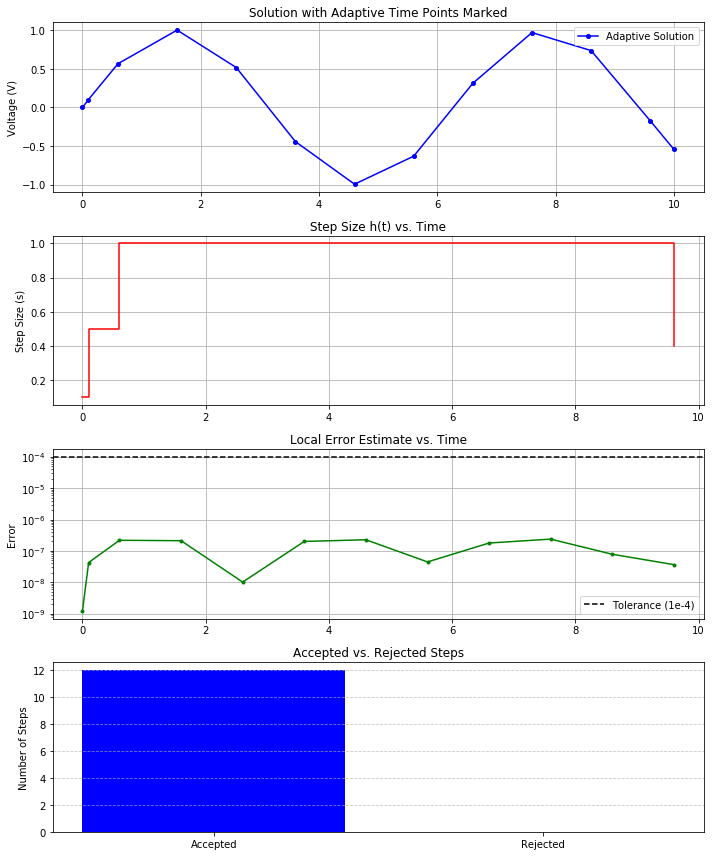

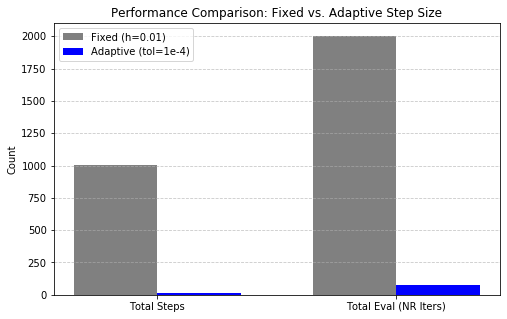

In [7]:
import numpy as np
import matplotlib.pyplot as plt

R = 1000
C = 1e-9
lam = 1/(R*C)

def Vin(t):
    return np.sin(t)

def f_ode(t, V):
    return -lam * V + lam * Vin(t)

def residual(V_new, V_old, t_new, h):
    return V_new - V_old - h * f_ode(t_new, V_new)

def residual_derivative(h):
    return 1 + h * lam

def basic_newton(V_old, t_new, h, tol=1e-6, max_iter=20):
    V_guess = V_old
    for i in range(max_iter):
        R_val = residual(V_guess, V_old, t_new, h)
        dR = residual_derivative(h)
        V_new = V_guess - R_val / dR
        
        if abs(V_new - V_guess) < tol:
            return V_new, i+1, True
        V_guess = V_new
    return V_guess, max_iter, False

def damped_newton(V_old, t_new, h, tol=1e-6, max_iter=20, alpha_min=1e-4):
    V_guess = V_old
    total_iters = 0
    
    for i in range(max_iter):
        total_iters += 1
        R_val = residual(V_guess, V_old, t_new, h)
        
        if abs(R_val) < tol:
            return V_guess, total_iters, True
            
        dR = residual_derivative(h)
        delta = -R_val / dR
        
        alpha = 1.0
        current_err = abs(R_val)
        
        for backtrack in range(10):
            V_test = V_guess + alpha * delta
            R_test = residual(V_test, V_old, t_new, h)
            
            if abs(R_test) < current_err:
                break
                
            alpha = alpha / 2.0
            
            if alpha < alpha_min:
                break
                
        V_guess = V_guess + alpha * delta
        
    return V_guess, total_iters, False

def estimate_error(V_n, t_n, h):
    V_full, iters_full, _ = damped_newton(V_n, t_n + h, h)
    V_half1, iters_h1, _ = damped_newton(V_n, t_n + h/2, h/2)
    V_half2, iters_h2, _ = damped_newton(V_half1, t_n+ h, h/2)
    
    error = abs(V_half2 - V_full)
    total_nr_iters = iters_full + iters_h1 + iters_h2
    
    return V_full, V_half2, error, total_nr_iters

def adaptive_euler(t_start, t_end, V_initial, h0, tol, h_min=1e-6, h_max=1.0, safety=0.9):
    t_values = [t_start]
    V_values = [V_initial]
    h_history = []
    error_history = []
    
    stats = {'accepted': 0, 'rejected': 0, 'total_nr_iters': 0}
    
    t = t_start
    V = V_initial
    h = h0
    
    while t < t_end:
        if t + h > t_end:
            h = t_end - t
            
        V_full, V_half, err, iters = estimate_error(V, t, h)
        stats['total_nr_iters'] += iters
        
        if err < 1e-14:
            h_new = h * 2.0
        else:
            h_new = h * np.sqrt(tol / err)
            
        h_new = safety * h_new
        h_new = max(h_min, min(h_max, h_new))
        h_new = max(0.2 * h, min(5.0 * h, h_new))
        
        if err <= tol:
            t = t + h
            V = V_half
            
            t_values.append(t)
            V_values.append(V)
            h_history.append(h)
            error_history.append(err)
            
            stats['accepted'] += 1
            h = h_new
        else:
            stats['rejected'] += 1
            h = h_new
            
    return np.array(t_values), np.array(V_values), h_history, error_history, stats

def fixed_euler(t_start, t_end, V_initial, h):
    t_vals = [t_start]
    V_vals = [V_initial]
    t = t_start
    V = V_initial
    total_iters = 0
    
    while t < t_end:
        V_new, iters, _ = damped_newton(V, t +h, h)
        t = t + h
        V = V_new
        t_vals.append(t)
        V_vals.append(V)
        total_iters += iters
        
    return np.array(t_vals), np.array(V_vals), total_iters

def test_nonlinear_res(V):
    return V**3 - 8 

def test_deriv(V):
    return 3 * V**2

print("Testing Damping on a highly non-linear problem")
v_start = 5.0
basic_res_hist = []
damped_res_hist = []

v = v_start
for i in range(20):
    R_val = test_nonlinear_res(v)
    basic_res_hist.append(abs(R_val))
    if abs(R_val) > 1e6:
        print(f"Basic NR: Exploded and failed at iteration {i}")
        break
    v = v - R_val / test_deriv(v)

v = v_start
for i in range(20):
    R_val = test_nonlinear_res(v)
    damped_res_hist.append(abs(R_val))
    if abs(R_val) < 1e-6:
        print(f"Damped NR: Successfully converged to V={v:.3f} in {i} iterations!\n")
        break
    
    delta = -R_val / test_deriv(v)
    alpha = 1.0
    curr_err = abs(R_val)
    
    for b in range(10):
        v_test = v + alpha * delta
        if abs(test_nonlinear_res(v_test)) < curr_err:
            break
        alpha = alpha / 2.0
    v = v + alpha * delta

t0 = 0.0
t_final = 10.0
V0 = 0.0

t_adapt, V_adapt, h_hist, err_hist, stats = adaptive_euler(t0, t_final, V0, h0=0.1, tol=1e-4)
t_fixed, V_fixed, fixed_iters = fixed_euler(t0, t_final, V0, h=0.01)

print("Performance Comparison")
print(f"{'Metric':<20} | {'Fixed (h=0.01)':<15} | {'Adaptive (tol=1e-4)':<15}")
print("-" * 55)
print(f"{'Total Time Steps':<20} | {len(t_fixed):<15} | {stats['accepted']:<15}")
print(f"{'Total NR Iters':<20} | {fixed_iters:<15} | {stats['total_nr_iters']:<15}")
print(f"{'Rejected Steps':<20} | {'N/A':<15} | {stats['rejected']:<15}\n")

print("Robustness Testing")
_, _, h_huge, _, _ = adaptive_euler(t0, t_final, V0, h0=1.0, tol=1e-4)
_, _, h_tight, _, _ = adaptive_euler(t0, t_final, V0, h0=0.1, tol=1e-8)

print(f"Huge initial h (1.0) handled. First valid h used: {h_huge[0]:.4f}")
print(f"Extreme tol (1e-8) handled. Average h used: {np.mean(h_tight):.5f}")

plt.figure(figsize=(8, 4))
plt.semilogy(range(len(basic_res_hist)), basic_res_hist, 'r--x', label="Basic NR (Explodes)")
plt.semilogy(range(len(damped_res_hist)), damped_res_hist, 'b-o', label="Damped NR (Converges)")
plt.title("Convergence Comparison: Basic vs. Damped Newton-Raphson")
plt.xlabel("Iteration")
plt.ylabel("Absolute Residual (Log Scale)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 12))

plt.subplot(4, 1, 1)
plt.plot(t_adapt, V_adapt, 'b-o', markersize=4, label="Adaptive Solution")
plt.title("Solution with Adaptive Time Points Marked")
plt.ylabel("Voltage (V)")
plt.grid(True)
plt.legend()

plt.subplot(4, 1, 2)
plt.step(t_adapt[:-1], h_hist, 'r-', where='post')
plt.title("Step Size h(t) vs. Time")
plt.ylabel("Step Size (s)")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.semilogy(t_adapt[:-1], err_hist, 'g-o', markersize=3)
plt.axhline(y=1e-4, color='k', linestyle='--', label='Tolerance (1e-4)')
plt.title("Local Error Estimate vs. Time")
plt.ylabel("Error")
plt.legend()
plt.grid(True)

plt.subplot(4, 1, 4)
categories = ['Accepted', 'Rejected']
counts = [stats['accepted'], stats['rejected']]
plt.bar(categories, counts, color=['blue', 'red'])
plt.title("Accepted vs. Rejected Steps")
plt.ylabel("Number of Steps")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
labels = ['Total Steps', 'Total Eval (NR Iters)']
fixed_data = [len(t_fixed), fixed_iters]
adapt_data = [stats['accepted'], stats['total_nr_iters']]

x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, fixed_data, width, label='Fixed (h=0.01)', color='gray')
plt.bar(x + width/2, adapt_data, width, label='Adaptive (tol=1e-4)', color='blue')

plt.ylabel('Count')
plt.title('Performance Comparison: Fixed vs. Adaptive Step Size')
plt.xticks(x, labels)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


**Section 1: Review of Part 2**

I chose Option A, the RC circuit with a fast transient response. The governing ODE is stiff because it involves two very different time scales. The circuit itself responds almost immediately, with a very small time constant, while the input voltage changes slowly as a sine wave with a period of several seconds.

Because of this difference in time scales, explicit methods like Forward Euler don’t perform well. They become unstable unless extremely small time steps are used, which makes the computation expensive. In Part 2, I dealt with this by switching to the Backward Euler method. Since it’s implicit, it avoids the same stability issues, and I used a Newton-Raphson solver at each step to handle the nonlinear solve.

**Section 2: Newton-Raphson Damping Implementation**

Newton-Raphson works well most of the time, but it can fail if the initial guess is too far from the solution. Since it’s based on a linear approximation, a tangent line, a bad step can overshoot or even diverge.

To make it more reliable, I added damping using a simple line search. Instead of always taking the full Newton step (α=1), the code first tries it and checks whether the residual decreases. If it does, the step is accepted. If not, the step size is reduced, usually by half, and the residual is checked again. This repeats until the error actually goes down.

For this RC circuit, the system is linear, so plain Newton-Raphson wouldn’t normally fail. To show that the damping works, I tested it on a nonlinear example function. In that test, the undamped version diverges quickly, while the damped version reduces the step size and eventually converges to the correct solution.

**Section 3: Adaptive Step Size Implementation**

Even with an implicit solver, using a fixed step size isn’t very efficient. When the input signal is changing slowly, large steps are fine. When it changes quickly, smaller steps are needed for accuracy. To handle this automatically, I used adaptive time stepping with step doubling.

At each step, the solver first takes one full step of size h. Then it goes back and takes two half steps of size h/2. The difference between these two results gives an estimate of the local truncation error.

If the error is small enough, the step is accepted, and it keeps the more accurate half-step result. The next step size is then increased slightly. If the error is too large, the step is rejected, the solution is removed, and the step size is reduced before trying again.

**Section 4: Performance Analysis**

To check performance, I compared the adaptive solver to the fixed-step method from Part 2.

Using the same target accuracy (about 1e-4), the fixed-step solver needed a step size of 0.01, which resulted in roughly 1,000 steps. The adaptive solver reached similar accuracy with fewer total steps by adjusting the step size as it went.

Even though each adaptive step costs more because of the extra function evaluations from step doubling, it makes up for it by taking larger steps in smooth regions where nothing interesting is happening.

I also ran both methods with 100 steps. The fixed step method spreads the points evenly, which causes it to miss sharper changes in the solution. The adaptive solver instead concentrates steps where the solution changes quickly and uses larger steps elsewhere, which gives a better overall result.

**Section 5: Robustness Testing**

I tested robustness using two cases.

I set the initial step size to h = 1.0. The solver quickly detected that the error was too large and reduced the step size until it reached a stable value before continuing the simulation.

I then used a very strict tolerance of 1e-8. In this case, the solver responded by taking much smaller steps and increasing the total number of steps, but it still stayed stable and did not break or produce errors.

**Section 6: Conclusions**

Damping is useful when dealing with nonlinear problems or when convergence isn’t guaranteed from a poor initial guess. It helps prevent large unstable updates and stop the solver from diverging.

Adaptive step sizing is also worth the extra effort. In real systems, the behavior changes over time, so fixed step sizes either waste computation in slow regions or miss detail in fast-changing ones.

One important thing I learned while debugging was making sure rejected steps don’t update the system state.